In [1]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/week1_features.csv")
df.columns = df.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace(' ', '_', regex=False)

feature_cols = [col for col in df.columns if 'roll' in col]
X = df[feature_cols]
y = df["Machine_failure"]
print("Shape:", X.shape)
print("Class distribution:", y.value_counts().to_dict())

Shape: (10000, 50)
Class distribution: {0: 9661, 1: 339}


In [3]:
skf = StratifiedKFold(n_splits=5)
baseline_f1 = []
baseline_preds = []
true_labels = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    baseline_preds.extend(y_pred)
    true_labels.extend(y_test)
    
    f1 = f1_score(y_test, y_pred, average='macro')
    baseline_f1.append(f1)
    print(f"Fold {fold+1} Baseline F1: {f1:.4f}")

print(f"\nBaseline Avg Macro F1: {sum(baseline_f1)/len(baseline_f1):.4f}")

Fold 1 Baseline F1: 0.4912
Fold 2 Baseline F1: 0.4890
Fold 3 Baseline F1: 0.3305
Fold 4 Baseline F1: 0.4868
Fold 5 Baseline F1: 0.5299

Baseline Avg Macro F1: 0.4655


In [4]:
smote = SMOTE(random_state=42)
skf2 = StratifiedKFold(n_splits=5)
smote_f1 = []
smote_preds = []
true_labels2 = []

for fold, (train_idx, test_idx) in enumerate(skf2.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    
    model2 = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
    model2.fit(X_resampled, y_resampled)
    y_pred = model2.predict(X_test)
    
    smote_preds.extend(y_pred)
    true_labels2.extend(y_test)
    
    f1 = f1_score(y_test, y_pred, average='macro')
    smote_f1.append(f1)
    print(f"Fold {fold+1} SMOTE F1: {f1:.4f}")

print(f"\nSMOTE Avg Macro F1: {sum(smote_f1)/len(smote_f1):.4f}")

Fold 1 SMOTE F1: 0.5060
Fold 2 SMOTE F1: 0.5047
Fold 3 SMOTE F1: 0.3190
Fold 4 SMOTE F1: 0.5004
Fold 5 SMOTE F1: 0.5684

SMOTE Avg Macro F1: 0.4797


In [5]:
print("=== Model Comparison ===")
print(f"Baseline Macro F1: {sum(baseline_f1)/len(baseline_f1):.4f}")
print(f"SMOTE Macro F1:    {sum(smote_f1)/len(smote_f1):.4f}")
improvement = sum(smote_f1)/len(smote_f1) - sum(baseline_f1)/len(baseline_f1)
print(f"Improvement: {improvement:.4f}")

=== Model Comparison ===
Baseline Macro F1: 0.4655
SMOTE Macro F1:    0.4797
Improvement: 0.0142


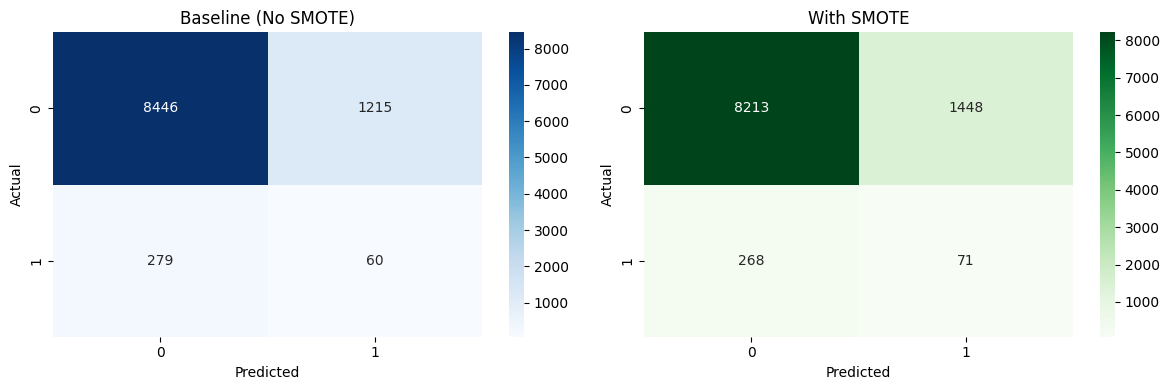

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm1 = confusion_matrix(true_labels, baseline_preds)
sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title("Baseline (No SMOTE)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm2 = confusion_matrix(true_labels2, smote_preds)
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title("With SMOTE")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix_comparison.png")
plt.show()

In [7]:
print("=== Baseline Minority Class ===")
print(classification_report(true_labels, baseline_preds, target_names=["No Failure", "Failure"]))

print("=== SMOTE Minority Class ===")
print(classification_report(true_labels2, smote_preds, target_names=["No Failure", "Failure"]))

=== Baseline Minority Class ===
              precision    recall  f1-score   support

  No Failure       0.97      0.87      0.92      9661
     Failure       0.05      0.18      0.07       339

    accuracy                           0.85     10000
   macro avg       0.51      0.53      0.50     10000
weighted avg       0.94      0.85      0.89     10000

=== SMOTE Minority Class ===
              precision    recall  f1-score   support

  No Failure       0.97      0.85      0.91      9661
     Failure       0.05      0.21      0.08       339

    accuracy                           0.83     10000
   macro avg       0.51      0.53      0.49     10000
weighted avg       0.94      0.83      0.88     10000



In [8]:
def batch_predict(model, data_path):
    df_new = pd.read_csv(data_path)
    df_new.columns = df_new.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace(' ', '_', regex=False)
    
    feature_cols = [col for col in df_new.columns if 'roll' in col]
    X_new = df_new[feature_cols]
    
    predictions = model.predict(X_new)
    df_new["predicted_failure"] = predictions
    
    print("Batch Predictions:")
    print(df_new["predicted_failure"].value_counts())
    df_new.to_csv("../data/batch_predictions.csv", index=False)
    print("Saved: batch_predictions.csv ✅")
    return df_new

result = batch_predict(model2, "../data/week1_features.csv")
result.head()

Batch Predictions:
predicted_failure
0    9667
1     333
Name: count, dtype: int64
Saved: batch_predictions.csv ✅


,UDI,Product_ID,Type,Air_temperature__K_,Process_temperature__K_,Rotational_speed__rpm_,Torque__Nm_,Tool_wear__min_,Machine_failure,TWF,...,Rotational_speed__rpm__rollmax_10,Torque__Nm__rollmin_5,Torque__Nm__rollmax_5,Torque__Nm__rollmin_10,Torque__Nm__rollmax_10,Tool_wear__min__rollmin_5,Tool_wear__min__rollmax_5,Tool_wear__min__rollmin_10,Tool_wear__min__rollmax_10,predicted_failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,1551.0,42.8,42.8,42.8,42.8,0.0,0.0,0.0,0.0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,1551.0,42.8,46.3,42.8,46.3,0.0,3.0,0.0,3.0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,1551.0,42.8,49.4,42.8,49.4,0.0,5.0,0.0,5.0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,1551.0,39.5,49.4,39.5,49.4,0.0,7.0,0.0,7.0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,1551.0,39.5,49.4,39.5,49.4,0.0,9.0,0.0,9.0,0
